# Aim

- To Explore the relationship between features
- To preprocess data
- To Check anomolies


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.impute import KNNImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import missingno as msno

In [ ]:
# Load the data from the CSV file
housing_data_path = '/content/drive/MyDrive/housing.csv'
housing_data = pd.read_csv(housing_data_path)

# Display the first few rows of the dataset to understand its structure
housing_data.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
housing_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [ ]:
housing_data.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

longitude               844
latitude                862
housing_median_age       52
total_rooms            5926
total_bedrooms         1923
population             3888
households             1815
median_income         12928
median_house_value     3842
ocean_proximity           5
dtype: int64

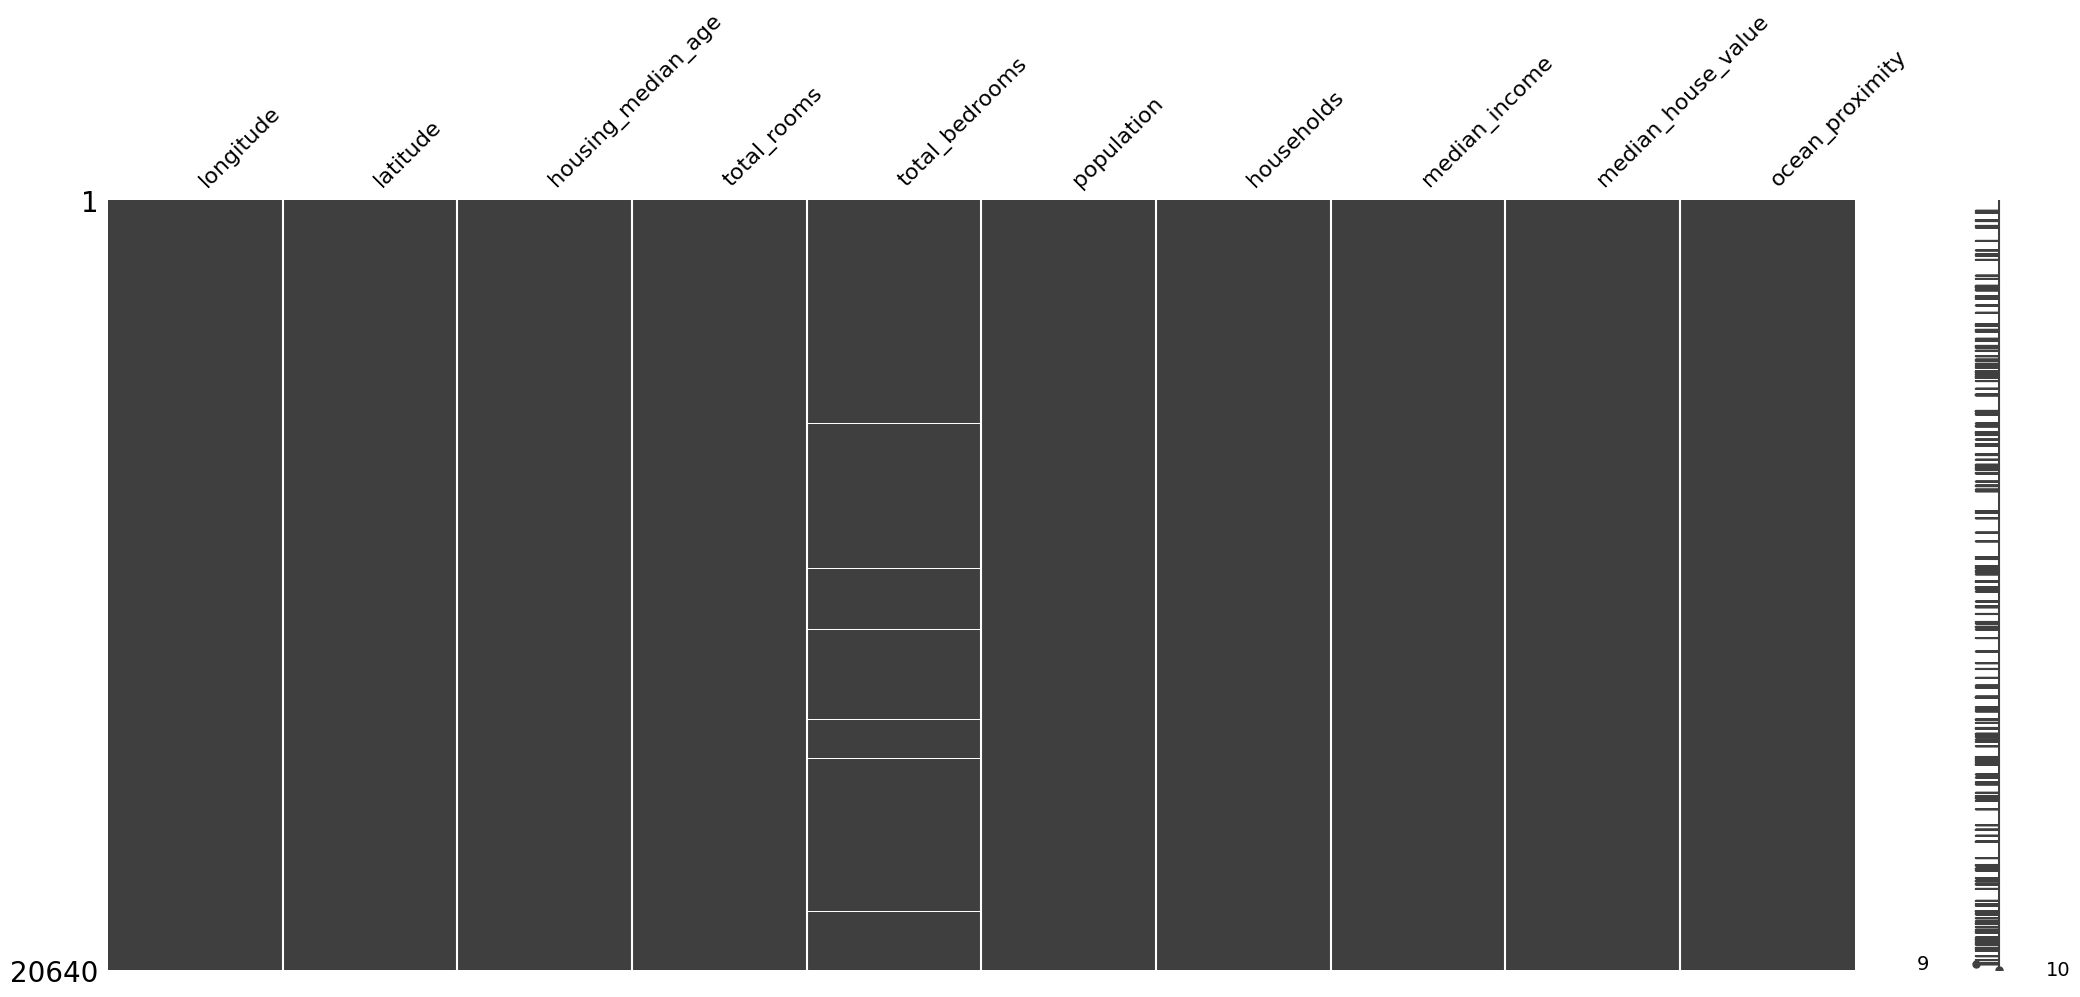

In [ ]:
msno.matrix(housing_data)
housing_data.nunique()

In [ ]:
housing_data['total_bedrooms'].unique()

array([ 129., 1106.,  190., ..., 3008., 1857., 1052.])

In [ ]:

housing_data['total_rooms'].unique()

array([  880.,  7099.,  1467., ...,  4598.,   272., 10035.])

In [ ]:
housing_data['housing_median_age'].unique()

array([41., 21., 52., 42., 50., 40., 49., 48., 51., 43.,  2., 46., 26.,
       20., 17., 36., 19., 23., 38., 35., 10., 16., 27., 39., 31., 29.,
       22., 37., 28., 34., 32., 47., 44., 30., 18., 45., 33., 24., 15.,
       14., 13., 25.,  5., 12.,  6.,  8.,  9.,  7.,  3.,  4., 11.,  1.])

In [ ]:
housing_data.isnull().sum()/ len(housing_data) *100

longitude             0.000000
latitude              0.000000
housing_median_age    0.000000
total_rooms           0.000000
total_bedrooms        1.002907
population            0.000000
households            0.000000
median_income         0.000000
median_house_value    0.000000
ocean_proximity       0.000000
dtype: float64

# As the housing dataset is arranged district and area wise. so I imputed mising values with its nearest proximity

In [ ]:
imputer = KNNImputer(n_neighbors=5)

# Reshape the input data
total_bedrooms_2d = housing_data['total_bedrooms'].values.reshape(-1, 1)

# Fit and transform the data
housing_data['total_bedrooms'] = imputer.fit_transform(total_bedrooms_2d)

In [ ]:
housing_data.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
housing_data.shape

(20640, 10)

In [ ]:
housing_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20640 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [ ]:
#!pip install skimpy -q

In [ ]:
pip install nbformat scikit-learn skimpy

  Using cached skimpy-0.0.14-py3-none-any.whl (16 kB)
  Using cached ipykernel-6.29.4-py3-none-any.whl (117 kB)
ERROR: Operation cancelled by user


In [ ]:
from skimpy import skim

# Below is the complete summary of data, its data type and details in one go

In [ ]:
skim(housing_data)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 20640  │ │ float64     │ 9     │                                                          │
│ │ Number of columns │ 10     │ │ string      │ 1     │                                                          │
│ └───────────────────┴────────┘ └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━━━━━━━┳━━━━━┳━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓  │
│ ┃ column_name          ┃ NA  ┃ NA %  ┃ mean    ┃ sd     ┃ p0    ┃ p25    ┃ p50    ┃ p75    ┃ p100   ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━━━╇━━━━━╇━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩  │
│ │ longitude            │   0 │     0 │    -120 │      2 │  -120 │   -120 │   -120 │   -120 │   -110 │ ▁▆▂▇▃  │  │
│ │ latitude             │   0 │     0 │      36 │    2.1 │    33 │     34 │     34 │     38 │     42 │ ▇▃▁▆▁  │  │
│ │ housing_median_age   │   0 │     0 │      29 │     13 │     1 │     18 │     29 │     37 │     52 │ ▂▆▇▇▇▅ │  │
│ │ total_rooms          │   0 │     0 │    2600 │   2200 │     2 │   1400 │   2100 │   3100 │  39000 │   ▇    │  │
│ │ total_bedrooms       │   0 │     0 │     540 │    420 │     1 │    300 │    440 │    640 │   6400 │   ▇▁   │  │
│ │ population           │   0 │     0 │    1400 │   1100 │     3 │    790 │   1200 │   1700 │  36000 │   ▇    │  │
│ │ households           │   0 │     0 │     500 │    380 │     1 │    280 │    410 │    600 │   6100 │   ▇▁   │  │
│ │ median_income        │   0 │     0 │     3.9 │    1.9 │   0.5 │    2.6 │    3.5 │    4.7 │     15 │  ▆▇▂   │  │
│ │ median_house_value   │   0 │     0 │  210000 │ 120000 │ 15000 │ 120000 │ 180000 │ 260000 │ 500000 │ ▃▇▆▃▂▂ │  │
│ └──────────────────────┴─────┴───────┴─────────┴────────┴───────┴────────┴────────┴────────┴────────┴────────┘  │
│                                                     string                                                      │
│ ┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┓  │
│ ┃ column_name                     ┃ NA     ┃ NA %       ┃ words per row              ┃ total words           ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━┩  │
│ │ ocean_proximity                 │      0 │          0 │                        1.7 │                 34724 │  │
│ └─────────────────────────────────┴────────┴────────────┴────────────────────────────┴───────────────────────┘  │
╰────────────────────────────────────────────────────── End ──────────────────────────────────────────────────────╯

# - To check the relationship of different features w.r.t housing price
- this plot shows that longitutde and latitude has nothing to do with any other feature. so we can drop them .
- they both are negatively correlated with each other.
- there are outlier in populaiton, total_bedrooms, total_rooms and house_holds.


In [ ]:
#sns.pairplot(housing_data,hue='median_house_value')

# correlation matrix to check relationship among population, median_income and median_housing_value

- it shows that population has nothing to do with house price and income.no correlation
- income and housing prices are correlated
- it must leads to the fact that housing prices are correlated with area----longitude and lattitude..lets che below

<ipython-input-18-a2e43cf3e1f5>:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr= housing_data.corr()


<Axes: >

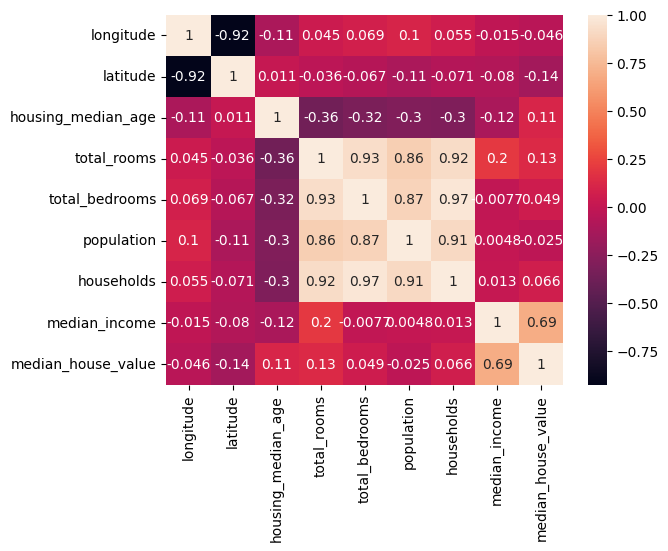

In [ ]:
corr= housing_data.corr()
sns.heatmap(corr,annot=True)

# Correlation Anaylsis, Shown above
- totoal_rooms and median_house_value and income are correlated
- populationan is correlated to house holds, total_rooms,total_bedroom
- whereas location and house value are negatively correlated.

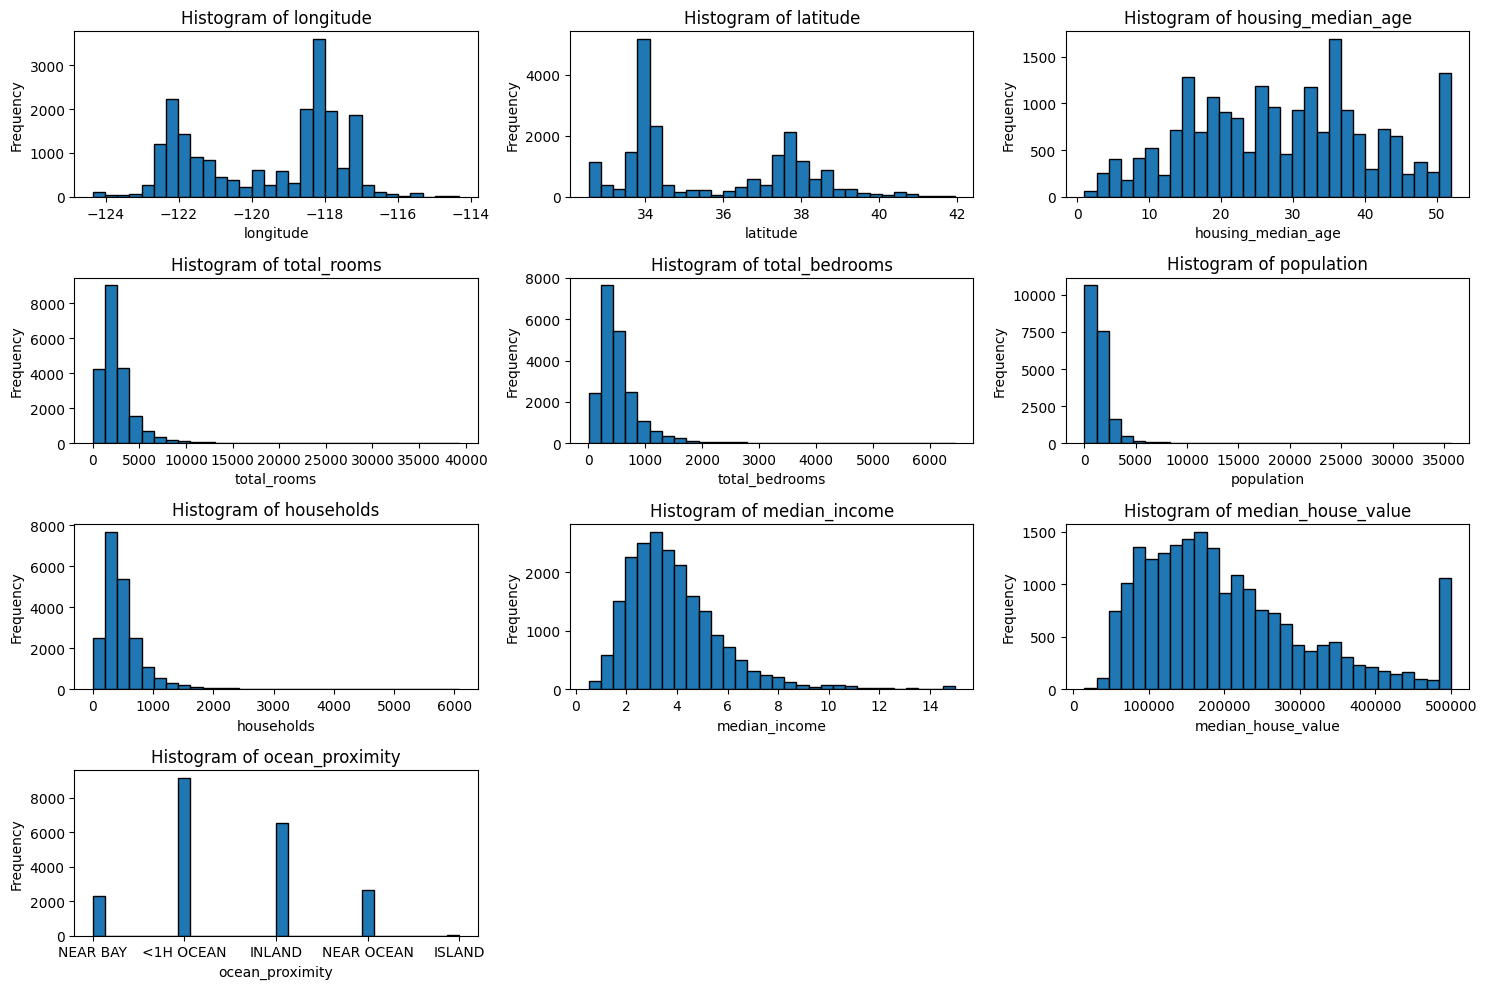

In [ ]:
features_to_plot = ['longitude','latitude','housing_median_age','total_rooms','total_bedrooms','population','households','median_income','median_house_value','ocean_proximity']

num_rows = 4
num_cols = 3

fig, axs = plt.subplots(num_rows, num_cols, figsize=(15, 10))  # Adjust figsize as needed

# Flatten the axs array to iterate over each subplot
axs = axs.flatten()

for i, feature in enumerate(features_to_plot):
    axs[i].hist(housing_data[feature], bins=30, edgecolor='black')
    axs[i].set_title(f'Histogram of {feature}')
    axs[i].set_xlabel(feature)
    axs[i].set_ylabel('Frequency')

# Hide any unused subplots
for j in range(len(features_to_plot), num_rows*num_cols):
    axs[j].axis('off')

plt.tight_layout()
plt.show()

plt.show()


# - To convert categorical column(ocean proximity ) into numerical .

In [ ]:
encoder = OrdinalEncoder()
reshape_ocean = housing_data['ocean_proximity'].values.reshape(-1,1)
housing_data['ocean_proximity'] = encoder.fit_transform(reshape_ocean)

In [ ]:
housing_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20640 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  float64
dtypes: float64(10)
memory usage: 1.6 MB


In [ ]:
housing_data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,3.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,3.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,3.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,3.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,3.0


# Descriptive Statistics

In [ ]:
#sorted_data[features_to_plot].describe().T
housing_data.describe().T   # .T command pivots table

,count,mean,std,min,25%,50%,75%,max
longitude,20640.0,-119.569704,2.003532,-124.3500,-121.8000,-118.4900,-118.01000,-114.3100
latitude,20640.0,35.631861,2.135952,32.5400,33.9300,34.2600,37.71000,41.9500
housing_median_age,20640.0,28.639486,12.585558,1.0000,18.0000,29.0000,37.00000,52.0000
total_rooms,20640.0,2635.763081,2181.615252,2.0000,1447.7500,2127.0000,3148.00000,39320.0000
total_bedrooms,20640.0,537.870553,419.266592,1.0000,297.0000,438.0000,643.25000,6445.0000
population,20640.0,1425.476744,1132.462122,3.0000,787.0000,1166.0000,1725.00000,35682.0000
households,20640.0,499.539680,382.329753,1.0000,280.0000,409.0000,605.00000,6082.0000
median_income,20640.0,3.870671,1.899822,0.4999,2.5634,3.5348,4.74325,15.0001
median_house_value,20640.0,206855.816909,115395.615874,14999.0000,119600.0000,179700.0000,264725.00000,500001.0000
ocean_proximity,20640.0,1.165843,1.420662,0.0000,0.0000,1.0000,1.00000,4.0000


# ** Data Cleaning **
- we need to drop outliers in total_rooms, total_bedrooms, population.
- We need to drop the unnecessary columns e.g., longitude and latitude


In [ ]:
housing_data.drop(columns=['longitude','latitude'], inplace=True)

In [ ]:
housing_data.columns

Index(['housing_median_age', 'total_rooms', 'total_bedrooms', 'population',
       'households', 'median_income', 'median_house_value', 'ocean_proximity'],
      dtype='object')

In [ ]:

# Calculate the IQR for the 'total_bedrooms' column
Q1 = housing_data['total_bedrooms'].quantile(0.25)
Q3 = housing_data['total_bedrooms'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for the outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Remove outliers
housing_data = housing_data[(housing_data['total_bedrooms'] >= lower_bound) & (housing_data['total_bedrooms'] <= upper_bound)]

# Display the first few rows of the dataset without outliers
print(housing_data.head())

   housing_median_age  total_rooms  total_bedrooms  population  households  \
0                41.0        880.0           129.0       322.0       126.0   
1                21.0       7099.0          1106.0      2401.0      1138.0   
2                52.0       1467.0           190.0       496.0       177.0   
3                52.0       1274.0           235.0       558.0       219.0   
4                52.0       1627.0           280.0       565.0       259.0   

   median_income  median_house_value  ocean_proximity  
0         8.3252            452600.0              3.0  
1         8.3014            358500.0              3.0  
2         7.2574            352100.0              3.0  
3         5.6431            341300.0              3.0  
4         3.8462            342200.0              3.0  


In [ ]:
# Calculate the IQR for the 'population' column
Q1 = housing_data['population'].quantile(0.25)
Q3 = housing_data['population'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for the outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Remove outliers
housing_data = housing_data[(housing_data['population'] >= lower_bound) & (housing_data['population'] <= upper_bound)]

# Display the first few rows of the dataset without outliers
print(housing_data.head())

   housing_median_age  total_rooms  total_bedrooms  population  households  \
0                41.0        880.0           129.0       322.0       126.0   
1                21.0       7099.0          1106.0      2401.0      1138.0   
2                52.0       1467.0           190.0       496.0       177.0   
3                52.0       1274.0           235.0       558.0       219.0   
4                52.0       1627.0           280.0       565.0       259.0   

   median_income  median_house_value  ocean_proximity  
0         8.3252            452600.0              3.0  
1         8.3014            358500.0              3.0  
2         7.2574            352100.0              3.0  
3         5.6431            341300.0              3.0  
4         3.8462            342200.0              3.0  


In [ ]:
# Calculate the IQR for the 'total_rooms' column
Q1 = housing_data['total_rooms'].quantile(0.25)
Q3 = housing_data['total_rooms'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for the outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Remove outliers
housing_data = housing_data[(housing_data['total_rooms'] >= lower_bound) & (housing_data['total_rooms'] <= upper_bound)]

# Display the first few rows of the dataset without outliers
print(housing_data.head())

   housing_median_age  total_rooms  total_bedrooms  population  households  \
0                41.0        880.0           129.0       322.0       126.0   
2                52.0       1467.0           190.0       496.0       177.0   
3                52.0       1274.0           235.0       558.0       219.0   
4                52.0       1627.0           280.0       565.0       259.0   
5                52.0        919.0           213.0       413.0       193.0   

   median_income  median_house_value  ocean_proximity  
0         8.3252            452600.0              3.0  
2         7.2574            352100.0              3.0  
3         5.6431            341300.0              3.0  
4         3.8462            342200.0              3.0  
5         4.0368            269700.0              3.0  


# different features in the Dataset has different value ranges .
- Need to apply Standardization to convert data into same range.

In [ ]:
housing_data['housing_median_age'] = housing_data['housing_median_age'].astype(float)
housing_data.dtypes

housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity       float64
dtype: object

In [ ]:
numerical_features = housing_data.select_dtypes(include = ['int64', 'float64'] )
#scalar = StandardScaler()
#housing_data = scalar.fit_transform(numerical_features)
#housing_data


In [ ]:
# Identify numerical and categorical features
num_attribs = ['housing_median_age', 'total_rooms', 'total_bedrooms', 'population',
       'households', 'median_income', 'median_house_value', 'ocean_proximity']
cat_attribs = ['ocean_proximity']

In [ ]:
# Create a preprocessing pipeline for numerical attributes
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('std_scaler', StandardScaler()),
])

In [ ]:
# Combine numerical and categorical transformations
full_pipeline = ColumnTransformer([
    ('num', num_pipeline, num_attribs),
    ('cat', OneHotEncoder(), cat_attribs),
])

In [ ]:
# Preprocess the data using the full pipeline
X_prepared = full_pipeline.fit_transform(housing_data)
# Assuming 'median_house_value' is a column in your housing_data
y = housing_data['median_house_value']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_prepared, y, test_size=0.2, random_state=42)


# **SVM**

In [ ]:
# Train the SVR model
svr = SVR(kernel='linear', C=300, epsilon=0.1)
svr.fit(X_train, y_train)


SVR(C=300, kernel='linear')

In [ ]:
# Make predictions and evaluate the model
y_pred = svr.predict(X_test)

In [ ]:
# Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred)
print(f'Mean Absolute Error: {mae}')

# Root Mean Squared Error (RMSE)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f'Root Mean Squared Error: {rmse}')

# R-squared (Coefficient of Determination)
r2 = r2_score(y_test, y_pred)
print(f'R-squared: {r2}')


Mean Absolute Error: 0.05195493419422568
Root Mean Squared Error: 0.057648924367824476
R-squared: 0.9999999999997549


In [ ]:
# Assuming std_dev and mean are the standard deviation and mean of the original median_house_value
std_dev = housing_data['median_house_value'].std()
mean = housing_data['median_house_value'].mean()

# Rescale the metrics back to the original units
original_mae = mae * std_dev
original_rmse = rmse * std_dev

print(f'Original Mean Absolute Error: {original_mae}')
print(f'Original Root Mean Squared Error: {original_rmse}')


Original Mean Absolute Error: 6013.197160182749
Original Root Mean Squared Error: 6672.212248412773


# Visulaization of Results

In [ ]:
import matplotlib.pyplot as plt

# Scatter plot for actual vs predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.title('Actual vs. Predicted Values')
plt.xlabel('Actual Median House Value')
plt.ylabel('Predicted Median House Value')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=4)  # Diagonal line for reference
plt.show()


In [ ]:
import matplotlib.pyplot as plt

# Calculate residuals
residuals = y_test - y_pred

# Plotting residuals with different colors for positive and negative values
plt.figure(figsize=(10, 6))
plt.scatter(y_pred[residuals >= 0], residuals[residuals >= 0], alpha=0.5, color='blue', label='Positive Residuals')
plt.scatter(y_pred[residuals < 0], residuals[residuals < 0], alpha=0.5, color='red', label='Negative Residuals')
plt.title('Residuals vs. Predicted Values')
plt.xlabel('Predicted Median House Value')
plt.ylabel('Residuals')
plt.axhline(y=0, color='k', linestyle='--')
plt.legend()
plt.show()


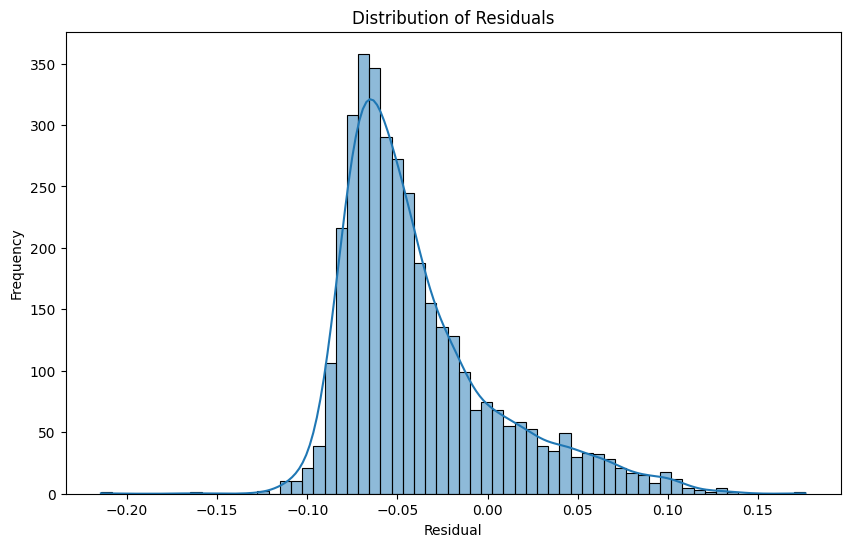

In [ ]:
residuals = y_test - y_pred
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True)
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals')
plt.show()


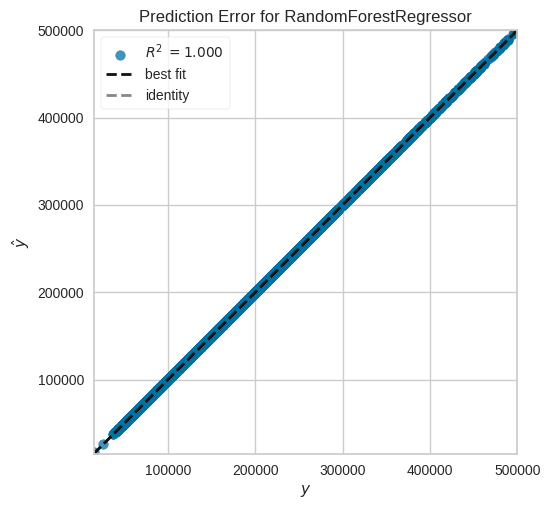

<Axes: title={'center': 'Prediction Error for RandomForestRegressor'}, xlabel='$y$', ylabel='$\\hat{y}$'>

In [ ]:

from yellowbrick.regressor import PredictionError

visualizer = PredictionError(random_forest)
visualizer.fit(X_train, y_train)  # Fit the training data to the visualizer
visualizer.score(X_test, y_test)  # Evaluate the model on the test data
visualizer.show()
